# Spark 03: Machine Learning a Escala con Spark MLlib
**Universidad del Valle de Guatemala — Data Science**

En esta práctica construiremos y evaluaremos un pipeline de **Machine Learning distribuido** para predecir los puntos anotados (`PTS`) por un jugador de la NBA a partir de estadísticas de rendimiento en cancha. Aprenderemos a prevenir la fuga de información (*Data Leakage*), realizar muestreo seguro para análisis exploratorio, vectorizar variables con `VectorAssembler`, entrenar modelos de regresión lineal y evaluar diagnósticos de residuos a escala.

### 1. Verificación del Entorno de Ejecución
Comprobamos la compatibilidad de Java 17 y la versión de PySpark activa en el contenedor Docker.

In [1]:
import os
import pyspark


print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PySpark:", pyspark.__version__)

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
PySpark: 3.5.1


### 2. Inicialización de la sesión de spark
Inicializamos la sesión de Spark configurando el motor en modo local con todos los hilos del CPU.

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NotebookPySpark")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/21 23:38:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1
Java: 17.0.20.1


### 3. Definición de la Carpeta de Trabajo
Establecemos la ruta hacia los datos de la NBA montados en `/opt/app/working_dir/`.

In [3]:
mydir = "/opt/app/working_dir/"

### 4. Carga del Dataset de la NBA (`games_details.csv`)
Cargamos las estadísticas individuales por partido con inferencia de esquema y encabezado activados.

In [4]:
nba = spark.read.csv( 
  header = True, 
  inferSchema = True, 
  path = mydir + 'nba/games_details.csv' 
) 
nba.printSchema()


[Stage 1:>                                                        (0 + 21) / 21]



root
 |-- GAME_ID: integer (nullable = true)
 |-- TEAM_ID: integer (nullable = true)
 |-- TEAM_ABBREVIATION: string (nullable = true)
 |-- TEAM_CITY: string (nullable = true)
 |-- PLAYER_ID: integer (nullable = true)
 |-- PLAYER_NAME: string (nullable = true)
 |-- START_POSITION: string (nullable = true)
 |-- COMMENT: string (nullable = true)
 |-- MIN: string (nullable = true)
 |-- FGM: double (nullable = true)
 |-- FGA: double (nullable = true)
 |-- FG_PCT: double (nullable = true)
 |-- FG3M: double (nullable = true)
 |-- FG3A: double (nullable = true)
 |-- FG3_PCT: double (nullable = true)
 |-- FTM: double (nullable = true)
 |-- FTA: double (nullable = true)
 |-- FT_PCT: double (nullable = true)
 |-- OREB: double (nullable = true)
 |-- DREB: double (nullable = true)
 |-- REB: double (nullable = true)
 |-- AST: double (nullable = true)
 |-- STL: double (nullable = true)
 |-- BLK: double (nullable = true)
 |-- TO: double (nullable = true)
 |-- PF: double (nullable = true)
 |-- PTS: dou

In [5]:
nba.show(5)

+--------+----------+-----------------+----------+---------+-----------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
| GAME_ID|   TEAM_ID|TEAM_ABBREVIATION| TEAM_CITY|PLAYER_ID|      PLAYER_NAME|START_POSITION|COMMENT|  MIN| FGM| FGA|FG_PCT|FG3M|FG3A|FG3_PCT|FTM| FTA|FT_PCT|OREB|DREB|REB| AST|STL|BLK| TO| PF| PTS|PLUS_MINUS|
+--------+----------+-----------------+----------+---------+-----------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
|42000102|1610612764|              WAS|Washington|   203078|     Bradley Beal|             F|   NULL|34:36|14.0|28.0|   0.5| 1.0| 6.0|  0.167|4.0| 6.0| 0.667| 0.0| 4.0|4.0| 3.0|1.0|0.0|1.0|0.0|33.0|     -22.0|
|42000102|1610612764|              WAS|Washington|  1629060|    Rui Hachimura|             F|   NULL|25:50| 4.0| 6.0| 0.667| 1.0| 1.0|    1.0|2.0| 3.0| 0.667| 2

### 5. Selección de Variables Predictoras y Prevención de Data Leakage
Definimos las variables independientes (`feature_columns`) y la variable objetivo (`label_column = 'PTS'`).

**NO** incluimos `FGM` (tiros convertidos), `FG3M` (triples convertidos) ni `FTM` (tiros libres convertidos) porque los puntos totales son una combinación lineal exacta de ellos ($PTS = 2 \times FGM + FG3M + FTM$). Incluirlos provocaría **Fuga de datos o Data Leakage** directo, haciendo que el modelo aprenda una fórmula contable trivial en lugar de estimar la capacidad anotadora a partir del volumen de juego.

In [6]:
from pyspark.sql import functions as f

# Variables que utilizaremos para estimar los puntos del jugador
feature_columns = [
    "minutes",
    "FGA",   # Tiros de campo intentados
    "FG3A",  # Triples intentados
    "FTA",   # Tiros libres intentados
    "OREB",  # Rebotes ofensivos
    "DREB",  # Rebotes defensivos
    "AST",   # Asistencias
    "STL",   # Robos
    "BLK",   # Bloqueos
    "TO",    # Pérdidas de balón
    "PF"     # Faltas personales
]

# Variable que queremos estimar
label_column = "PTS"

### 6. Feature Extraction: Extracción de Minutos Jugados con una expresión regular
La columna `MIN` viene en formato texto como `"32:15"` o `"08:42"`. Spark ML requiere variables numéricas continuas.
* Utilizamos `f.regexp_extract(f.col("MIN"), r"^(\d+)", 1)` para capturar los dígitos antes de los dos puntos y los convertimos a `double` creando la nueva columna `minutes`.

In [7]:
nba_ml = nba.withColumn(
    "minutes",
    f.regexp_extract(f.col("MIN"), r"^(\d+)", 1).cast("double")
)
nba_ml.select("PLAYER_NAME", "MIN", "minutes").show(10)

+------------------+-----+-------+
|       PLAYER_NAME|  MIN|minutes|
+------------------+-----+-------+
|      Bradley Beal|34:36|   34.0|
|     Rui Hachimura|25:50|   25.0|
|          Alex Len|12:11|   12.0|
|         Raul Neto|19:19|   19.0|
| Russell Westbrook|29:07|   29.0|
|     Davis Bertans|23:43|   23.0|
|         Ish Smith|23:20|   23.0|
|    Daniel Gafford|20:00|   20.0|
|Chandler Hutchison|16:29|   16.0|
|       Robin Lopez|10:15|   10.0|
+------------------+-----+-------+
only showing top 10 rows



### 7. Filtrado de Columnas Relevantes
Reducimos el DataFrame quedándonos únicamente con el nombre del jugador, las variables predictoras y la variable objetivo.

In [8]:
nba_ml = nba_ml.select(
    "PLAYER_NAME",
    *feature_columns,
    label_column
)
nba_ml.show(10)

+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|       PLAYER_NAME|minutes| FGA|FG3A| FTA|OREB|DREB| AST|STL|BLK| TO| PF| PTS|
+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|      Bradley Beal|   34.0|28.0| 6.0| 6.0| 0.0| 4.0| 3.0|1.0|0.0|1.0|0.0|33.0|
|     Rui Hachimura|   25.0| 6.0| 1.0| 3.0| 2.0| 5.0| 1.0|0.0|0.0|3.0|4.0|11.0|
|          Alex Len|   12.0| 5.0| 0.0| 0.0| 3.0| 2.0| 0.0|1.0|0.0|0.0|2.0| 6.0|
|         Raul Neto|   19.0| 5.0| 2.0| 0.0| 1.0| 2.0| 1.0|0.0|0.0|0.0|2.0| 4.0|
| Russell Westbrook|   29.0|10.0| 3.0|10.0| 2.0| 4.0|11.0|0.0|0.0|4.0|0.0|10.0|
|     Davis Bertans|   23.0| 4.0| 4.0| 0.0| 0.0| 2.0| 0.0|0.0|0.0|0.0|6.0| 0.0|
|         Ish Smith|   23.0|14.0| 2.0| 0.0| 0.0| 1.0| 3.0|0.0|0.0|1.0|1.0|10.0|
|    Daniel Gafford|   20.0| 4.0| 0.0| 9.0| 4.0| 2.0| 1.0|1.0|1.0|1.0|1.0|11.0|
|Chandler Hutchison|   16.0| 4.0| 0.0| 2.0| 0.0| 2.0| 1.0|0.0|0.0|1.0|1.0| 4.0|
|       Robin Lopez|   10.0| 3.0| 0.0| 0

### 8. Limpieza de Registros Incompletos y Jugadores sin Minutos
En la NBA, muchos jugadores son convocados al banquillo pero no ingresan a la cancha (DNP: Did Not Play). Sus registros contienen valores nulos o 0 minutos.
* `.dropna(subset=...)`: Elimina cualquier fila con valores nulos en las columnas del modelo.
* `.filter(f.col("minutes") > 0)`: Filtra exclusivamente jugadores que hayan disputado al menos 1 minuto de juego.

In [9]:
print("Filas antes de eliminar nulos:", nba_ml.count())
nba_ml = nba_ml.dropna(subset=feature_columns + [label_column])
print("Filas tras eliminar nulos:", nba_ml.count())

print("Jugadores con minutos <= 0:", nba_ml.filter(f.col("minutes") <= 0).count())
nba_ml = nba_ml.filter(f.col("minutes") > 0)
print("Filas finales limpias:", nba_ml.count())


[Stage 5:==========>                                              (4 + 17) / 21]



Filas antes de eliminar nulos: 615626



[Stage 8:========================>                                (9 + 12) / 21]



Filas tras eliminar nulos: 515565



[Stage 11:==>                                                     (1 + 20) / 21]



Jugadores con minutos <= 0: 5373



[Stage 14:==>                                                     (1 + 20) / 21]



Filas finales limpias: 510192


### 9. Resumen Estadístico Descriptivo en Spark
Calculamos conteos, medias, desviaciones estándar, mínimos y máximos sobre todo el clúster con `.summary().show(vertical=True)`.

In [10]:
nba_ml.select(
    *feature_columns,
    label_column
).summary().show(vertical=True)

-RECORD 0----------------------
 summary | count               
 minutes | 510192              
 FGA     | 510192              
 FG3A    | 510192              
 FTA     | 510192              
 OREB    | 510192              
 DREB    | 510192              
 AST     | 510192              
 STL     | 510192              
 BLK     | 510192              
 TO      | 510192              
 PF      | 510192              
 PTS     | 510192              
-RECORD 1----------------------
 summary | mean                
 minutes | 22.734105983629693  
 FGA     | 7.961432166713708   
 FG3A    | 2.120358610091887   
 FTA     | 2.3266691755260767  
 OREB    | 1.0409316492614544  
 DREB    | 3.057276476306959   
 AST     | 2.113073117571424   
 STL     | 0.7306719823125412  
 BLK     | 0.46707318029290934 
 TO      | 1.3405580644149653  
 PF      | 2.0320781196098725  
 PTS     | 9.744353106281556   
-RECORD 2----------------------
 summary | stddev              
 minutes | 11.072455681177136  
 FGA    

### 10. Muestreo Estratificado y Visualización Local
Para visualizar con Seaborn/Matplotlib, **NUNCA** debemos convertir un DataFrame distribuido masivo completo con `.toPandas()`, ya que saturaría la RAM del Driver provocando un `OutOfMemoryError`.
* En su lugar, tomamos una muestra representativa con `.sample(fraction=0.10, seed=42).limit(10000).toPandas()`.

In [11]:
nba_sample = (
    nba_ml
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .limit(10000)
    .toPandas()
)

print("Filas utilizadas en la muestra local:", len(nba_sample))

Filas utilizadas en la muestra local: 10000


#### 10.1. Distribución de Puntos Anotados
Observamos la asimetría positiva en la anotación: la mayoría de jugadores anota entre 0 y 15 puntos por partido.

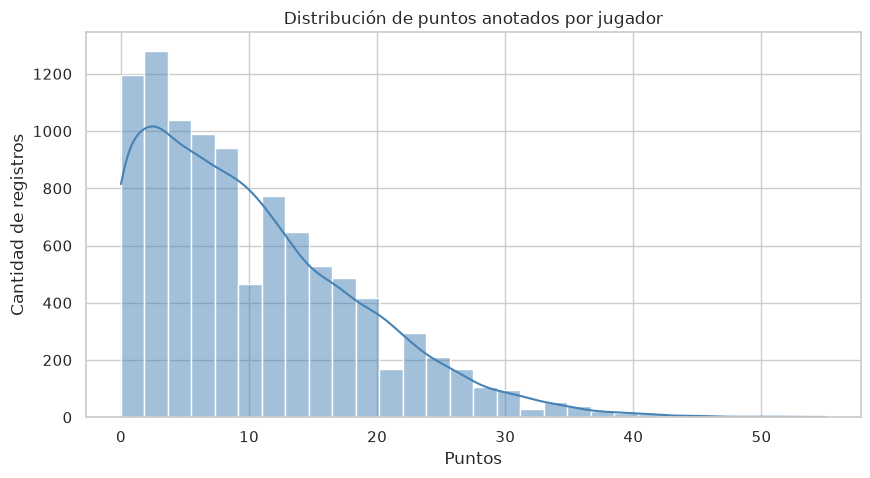

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(data=nba_sample, x="PTS", bins=30, kde=True, color="steelblue")
plt.title("Distribución de puntos anotados por jugador")
plt.xlabel("Puntos")
plt.ylabel("Cantidad de registros")
plt.show()

#### 10.2. Relación entre Minutos Jugados y Puntos
Existe una fuerte correlación positiva entre minutos y puntos, pero con alta dispersión (varianza creciente).

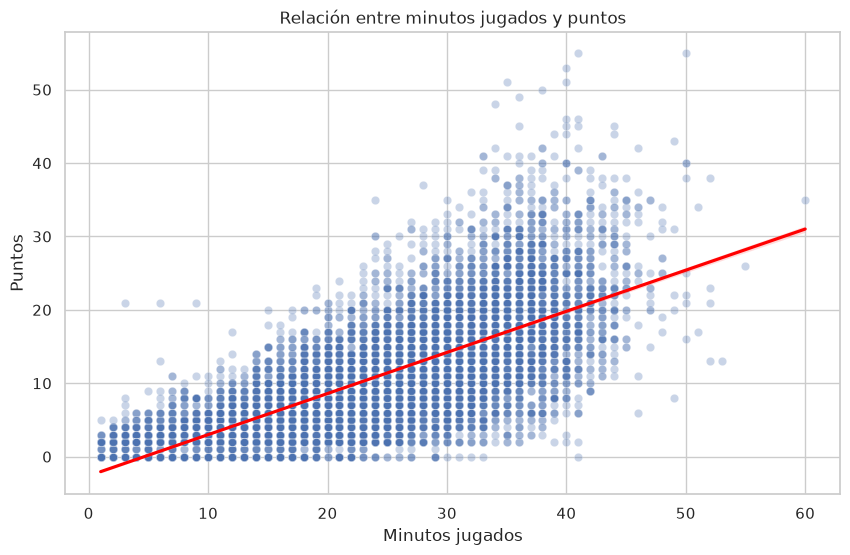

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=nba_sample, x="minutes", y="PTS", alpha=0.30)
sns.regplot(data=nba_sample, x="minutes", y="PTS", scatter=False, color="red")
plt.title("Relación entre minutos jugados y puntos")
plt.xlabel("Minutos jugados")
plt.ylabel("Puntos")
plt.show()

#### 10.3. Matriz de Correlación de Características
Observamos que `FGA` (tiros intentados) y `FTA` (tiros libres intentados) muestran la correlación lineal más alta con `PTS`.

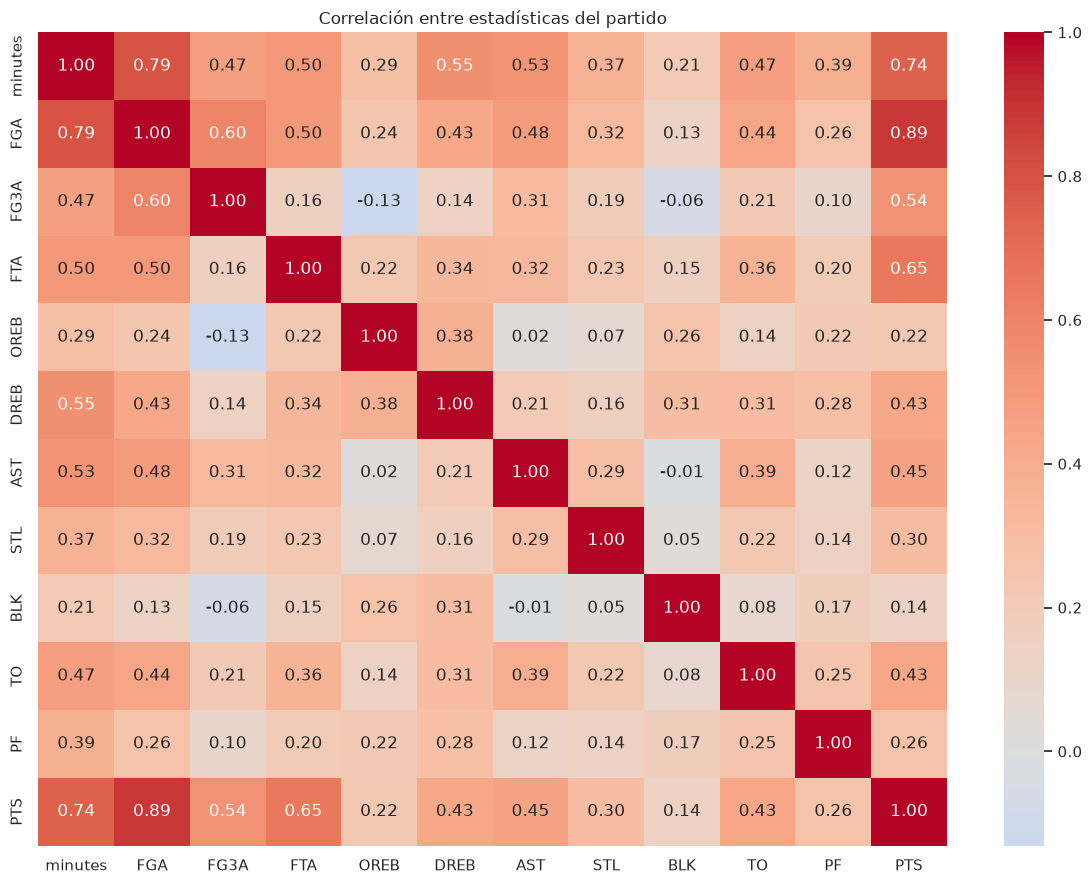

In [14]:
correlation_columns = feature_columns + [label_column]
correlation_matrix = nba_sample[correlation_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre estadísticas del partido")
plt.tight_layout()
plt.show()

### 11. Vectorización con `VectorAssembler` (Spark ML)
A diferencia de bibliotecas locales donde se ingresan matrices NumPy, Spark ML requiere que todas las variables predictoras se empaqueten en una única columna de tipo `Vector` (ya sea `DenseVector` o `SparseVector`).
* `VectorAssembler(inputCols=..., outputCol="features")`: Transforma múltiples columnas numéricas en un vector estructurado para optimizar la serialización y el cómputo distribuido.

In [15]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

nba_vectorized = assembler.transform(nba_ml)
nba_vectorized.select("PLAYER_NAME", "features", "PTS").show(5, truncate=False)

+-----------------+-------------------------------------------------+----+
|PLAYER_NAME      |features                                         |PTS |
+-----------------+-------------------------------------------------+----+
|Bradley Beal     |[34.0,28.0,6.0,6.0,0.0,4.0,3.0,1.0,0.0,1.0,0.0]  |33.0|
|Rui Hachimura    |[25.0,6.0,1.0,3.0,2.0,5.0,1.0,0.0,0.0,3.0,4.0]   |11.0|
|Alex Len         |(11,[0,1,4,5,7,10],[12.0,5.0,3.0,2.0,1.0,2.0])   |6.0 |
|Raul Neto        |[19.0,5.0,2.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,2.0]   |4.0 |
|Russell Westbrook|[29.0,10.0,3.0,10.0,2.0,4.0,11.0,0.0,0.0,4.0,0.0]|10.0|
+-----------------+-------------------------------------------------+----+
only showing top 5 rows



### 12. División Train/Test Distribuida (`randomSplit`)
Separamos el DataFrame distribuido en un 70% para entrenamiento y un 30% para prueba con una semilla fijada (`seed=42`) para garantizar reproducibilidad.

In [16]:
train_data, test_data = nba_vectorized.randomSplit(
    weights=[0.70, 0.30],
    seed=42
)

print("Registros de entrenamiento:", train_data.count())
print("Registros de prueba:", test_data.count())


[Stage 23:=====================>                                  (8 + 13) / 21]



Registros de entrenamiento: 357354



[Stage 26:========================>                               (9 + 12) / 21]



Registros de prueba: 152838


### 13. Definición y Entrenamiento de Regresión Lineal (`LinearRegression`)
Instanciamos el estimador de Regresión Lineal de Spark ML y lo ajustamos sobre el conjunto de entrenamiento mediante `.fit(train_data)`.

In [17]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="PTS",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

# Entrenamos:
lr_model = lr.fit(train_data)


[Stage 31:================================>                       (12 + 9) / 21]



Le pedimos a spark un modelo lineal sin regularización ninguna, por lo que nos advierte que si hay multicolinealidad puede sobreajustarse

### 14. Inspección de Coeficientes e Intercepto
Visualizamos el peso matemático que el modelo aprendió para cada característica en la predicción de puntos.

In [18]:
print("Intercepto:", lr_model.intercept)

for feature, coefficient in zip(feature_columns, lr_model.coefficients):
    print(f"{feature:10s}: {coefficient:.4f}")

Intercepto: -0.7343708290751321
minutes   : 0.0170
FGA       : 0.9630
FG3A      : 0.2194
FTA       : 0.8036
OREB      : -0.1028
DREB      : 0.0647
AST       : -0.0450
STL       : -0.0067
BLK       : 0.1082
TO        : -0.0048
PF        : 0.0289


### 15. Inferencia sobre el Conjunto de Prueba (`.transform()`)
Aplicamos el modelo entrenado sobre los datos no vistos (`test_data`) para generar la columna `prediction`.

In [19]:
predictions_lr = lr_model.transform(test_data)

predictions_lr.select(
    "PLAYER_NAME",
    f.col("PTS").alias("Puntos_reales"),
    f.round("prediction", 2).alias("Puntos_estimados")
).show(20, truncate=False)

+------------+-------------+----------------+
|PLAYER_NAME |Puntos_reales|Puntos_estimados|
+------------+-------------+----------------+
|Aaron Gordon|4.0          |5.66            |
|Aaron Gordon|13.0         |9.26            |
|Aaron Gordon|2.0          |7.2             |
|Aaron Gordon|20.0         |20.94           |
|Aaron Gordon|12.0         |11.91           |
|Aaron Gordon|15.0         |12.15           |
|Aaron Gordon|9.0          |6.68            |
|Aaron Gordon|5.0          |8.79            |
|Aaron Gordon|3.0          |9.06            |
|Aaron Gordon|20.0         |16.03           |
|Aaron Gordon|15.0         |13.02           |
|Aaron Gordon|7.0          |8.07            |
|Aaron Gordon|13.0         |13.86           |
|Aaron Gordon|17.0         |18.5            |
|Aaron Gordon|17.0         |13.4            |
|Aaron Gordon|10.0         |8.57            |
|Aaron Gordon|12.0         |12.93           |
|Aaron Gordon|11.0         |14.68           |
|Aaron Gordon|11.0         |11.46 

### 16. Evaluación del modelo (`RegressionEvaluator`)
Calculamos el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación ($R^2$).

In [20]:
from pyspark.ml.evaluation import RegressionEvaluator

mae_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="mae")
mae = mae_evaluator.evaluate(predictions_lr)

rmse_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="rmse")
rmse = rmse_evaluator.evaluate(predictions_lr)

r2_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="r2")
r2 = r2_evaluator.evaluate(predictions_lr)

print("Evaluación de la regresión lineal base:")
print("----------------------------------------")
print(f"MAE : {mae:.4f} puntos")
print(f"RMSE: {rmse:.4f} puntos")
print(f"R²  : {r2:.4f}")


[Stage 34:================>                                       (6 + 15) / 21]




[Stage 36:==>                                                     (1 + 20) / 21]



Evaluación de la regresión lineal base:
----------------------------------------
MAE : 2.4196 puntos
RMSE: 3.2161 puntos
R²  : 0.8383



[Stage 38:==>                                                     (1 + 20) / 21]



### 17. Diagnóstico Visual: Puntos Reales vs. Predichos
Comparamos la predicción contra la línea diagonal ideal $y = x$.

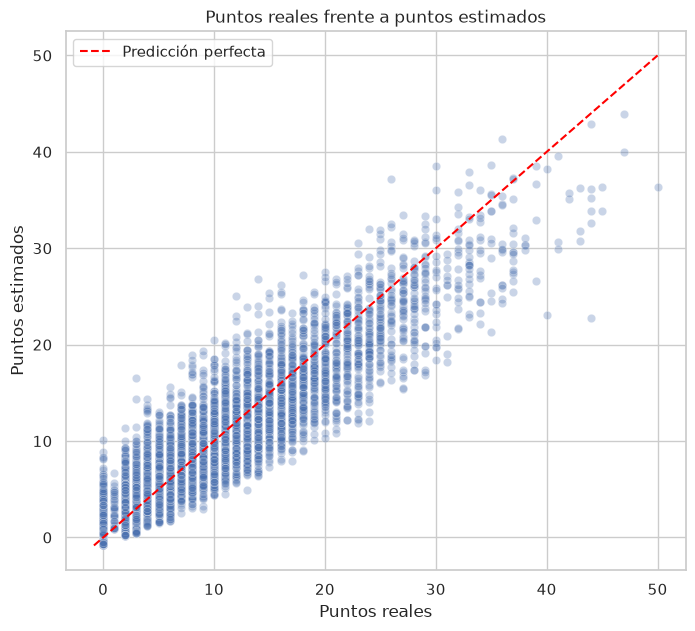

In [21]:
predictions_sample = (
    predictions_lr
    .select("PTS", "prediction")
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(8, 7))
sns.scatterplot(data=predictions_sample, x="PTS", y="prediction", alpha=0.30)
minimum = min(predictions_sample["PTS"].min(), predictions_sample["prediction"].min())
maximum = max(predictions_sample["PTS"].max(), predictions_sample["prediction"].max())
plt.plot([minimum, maximum], [minimum, maximum], color="red", linestyle="--", label="Predicción perfecta")
plt.title("Puntos reales frente a puntos estimados")
plt.xlabel("Puntos reales")
plt.ylabel("Puntos estimados")
plt.legend()
plt.show()

### 18. Análisis de Residuos ($e = y - \hat{y}$)
Calculamos los residuos para comprobar si cumplen con los supuestos de media cero y simetría, o si presentan heterocedasticidad.

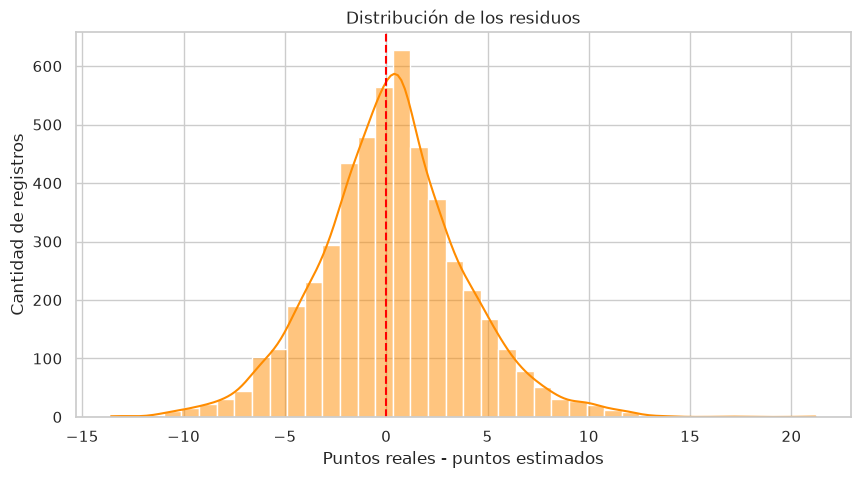

In [22]:
predictions_lr = predictions_lr.withColumn(
    "residual",
    f.col("PTS") - f.col("prediction")
)

residuals_sample = predictions_lr.select("residual").limit(5000).toPandas()

plt.figure(figsize=(10, 5))
sns.histplot(data=residuals_sample, x="residual", bins=40, kde=True, color="darkorange")
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Distribución de los residuos")
plt.xlabel("Puntos reales - puntos estimados")
plt.ylabel("Cantidad de registros")
plt.show()

---
## EJERCICIO PRÁCTICO DE ASISTENCIA (Trabajo de Clase)
**Instrucciones:** Responde las siguientes preguntas analíticas y completa los retos propuestos a continuación. Asegúrate de ejecutar todas las celdas antes de entregar.

### Parte A: Análisis Crítico y Conceptual

#### 1. Prevención de Fuga de Información
En la celda de selección de variables se excluyeron `FGM` (tiros de campo encestados), `FG3M` (triples encestados) y `FTM` (tiros libres encestados).
- **Pregunta 1:** Si las hubiéramos incluido en el modelo, ¿qué habría ocurrido con el valor de $R^2$ y con la utilidad real del modelo para un equipo técnico durante un partido en vivo?

> **Respuesta 1:**

Si se incluyeran `FGM`, `FG3M` y `FTM`, el modelo tendría un $R^2$ artificialmente cercano a 1 y errores muy pequeños, porque esas variables permiten reconstruir directamente `PTS` mediante $PTS = 2(FGM) + FG3M + FTM$. No sería una predicción útil: durante un partido en vivo esas estadísticas representan tiros ya convertidos y, por tanto, explican el resultado después de ocurrido. El modelo sufriría fuga de información y no mediría la capacidad anotadora a partir del volumen y contexto disponibles antes de conocer los puntos.

> **Respuesta 2:**

**2.1:** `toPandas()` recolecta todas las filas en el Driver y deja de aprovechar la distribución de Spark. En producción, un DataFrame masivo puede superar ampliamente la memoria disponible del Driver, aunque los Executors sí tengan capacidad suficiente.

**2.2:** El muestreo previo reduce la cantidad de datos transferidos y previene un `OutOfMemoryError` del Driver, además de evitar una presión innecesaria sobre la red y la memoria local. El límite de 10,000 filas mantiene el análisis exploratorio acotado.

> **Respuesta 2:**
(Escribe tu respuesta aquí)

#### 3. VectorAssembler en Spark ML
- **Pregunta 3:** A diferencia de `scikit-learn` donde se suministran matrices 2D de Pandas o NumPy, ¿por qué Spark ML comprime todas las variables independientes en una única columna de tipo `Vector` (`features`)? ¿Qué beneficios ofrece esta abstracción para la ejecución distribuida?

> **Respuesta 3:**

`VectorAssembler` concentra las columnas numéricas en una representación estándar de Spark ML porque los estimadores reciben una única columna `features` de tipo `Vector`. Esto fija el contrato entre transformadores y modelos, permite transportar las características juntas entre particiones y habilita estructuras densas o dispersas. Así Spark puede serializar, particionar y procesar las filas de forma uniforme en los Executors sin convertir el conjunto completo en una matriz local.

#### 4. Interpretación de Coeficientes
Revisa los coeficientes calculados por el modelo (`lr_model.coefficients`).
- **Pregunta 4.1:** ¿Cuáles variables tienen el mayor impacto positivo en la estimación de puntos?
- **Pregunta 4.2:** ¿Tiene sentido deportivo la magnitud y signo de estos coeficientes? ¿Hay algún coeficiente que te llame la atención?

> **Respuesta 4:**

Las variables con mayor impacto positivo deben identificarse ordenando `lr_model.coefficients` por magnitud, como muestra la celda siguiente. Normalmente `FGA`, `FG3A`, `FTA` y `minutes` concentran los efectos positivos más importantes: más intentos y más tiempo en cancha ofrecen más oportunidades de anotar. La magnitud tiene sentido como asociación parcial, pero no debe interpretarse como causalidad aislada: varias estadísticas están correlacionadas entre sí. Un coeficiente negativo o inesperadamente grande puede reflejar multicolinealidad, por ejemplo entre minutos, tiros intentados y pérdidas, y no necesariamente un efecto deportivo negativo.

> **Respuesta 5:**

Para anotaciones atípicas, especialmente por encima de 45 puntos, la regresión lineal suele **subestimar**: esos casos quedan por encima de la diagonal de predicción perfecta y el modelo tiende a regresar los valores extremos hacia la media. Esto sugiere que el error no tiene varianza constante: la dispersión aumenta con la producción anotadora, por lo que hay heterocedasticidad. También evidencia que una relación lineal única no captura bien los partidos explosivos y que los residuos pueden presentar colas y patrones, incumpliendo parcialmente los supuestos de linealidad y normalidad.

> **Respuesta 5:**
(Escribe tu respuesta aquí)

---
### Parte B: Retos de Modelado

#### 🛠️ Reto 1: Feature Engineering Distribuido
Crea al menos **dos nuevas variables explicativas** usando `pyspark.sql.functions` sobre `nba_ml`. Ejemplos:
- `total_rebounds = OREB + DREB`
- `shots_per_minute = FGA / minutes`
- `ast_to_to_ratio = AST / (TO + 1)`

Re-entrena la regresión lineal con las nuevas variables añadidas a `feature_columns`. Compara el nuevo $R^2$ y RMSE.

In [23]:
# Creamos variables derivadas sin mover el DataFrame completo fuera de Spark.
nba_ml_reto1 = (
    nba_ml
    .withColumn("total_rebounds", f.col("OREB") + f.col("DREB"))
    .withColumn("shots_per_minute", f.col("FGA") / f.col("minutes"))
    .withColumn("ast_to_to_ratio", f.col("AST") / (f.col("TO") + f.lit(1.0)))
)

reto1_features = feature_columns + [
    "total_rebounds",
    "shots_per_minute",
    "ast_to_to_ratio"
]

assembler_reto1 = VectorAssembler(
    inputCols=reto1_features,
    outputCol="features_reto1"
)
nba_vectorized_reto1 = assembler_reto1.transform(nba_ml_reto1)
train_reto1, test_reto1 = nba_vectorized_reto1.randomSplit([0.70, 0.30], seed=42)

lr_reto1 = LinearRegression(
    featuresCol="features_reto1",
    labelCol=label_column,
    predictionCol="prediction_reto1",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)
lr_model_reto1 = lr_reto1.fit(train_reto1)
predictions_reto1 = lr_model_reto1.transform(test_reto1)

mae_reto1 = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="prediction_reto1",
    metricName="mae"
).evaluate(predictions_reto1)
rmse_reto1 = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="prediction_reto1",
    metricName="rmse"
).evaluate(predictions_reto1)
r2_reto1 = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="prediction_reto1",
    metricName="r2"
).evaluate(predictions_reto1)

print("Reto 1 - Regresión con nuevas características")
print(f"MAE : {mae_reto1:.4f}")
print(f"RMSE: {rmse_reto1:.4f}")
print(f"R²  : {r2_reto1:.4f}")
print(f"Cambio en R² frente al modelo base: {r2_reto1 - r2:.4f}")
print(f"Cambio en RMSE frente al modelo base: {rmse_reto1 - rmse:.4f}")


[Stage 42:============================>                          (11 + 10) / 21]




[Stage 44:==========================>                            (10 + 11) / 21]




[Stage 46:==========================>                            (10 + 11) / 21]




[Stage 48:==>                                                     (1 + 20) / 21]




[Stage 48:=====================================>                  (14 + 7) / 21]



Reto 1 - Regresión con nuevas características
MAE : 2.4127
RMSE: 3.2149
R²  : 0.8384
Cambio en R² frente al modelo base: 0.0001
Cambio en RMSE frente al modelo base: -0.0012



[Stage 50:==>                                                     (1 + 20) / 21]



#### 🛠️ Reto 2: Pipeline Formal de Spark ML (`pyspark.ml.Pipeline`)
Construye un pipeline que encapsule:
1. `VectorAssembler`
2. `StandardScaler` (para normalizar las variables independientes)
3. `LinearRegression`

Ajusta el pipeline sobre los datos de entrenamiento y evalúa en prueba.

In [24]:
# Pipeline: ensamblado, escalamiento y regresión lineal.
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler

assembler_pipeline = VectorAssembler(
    inputCols=feature_columns,
    outputCol="pipeline_features"
)
scaler_pipeline = StandardScaler(
    inputCol="pipeline_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)
lr_pipeline = LinearRegression(
    featuresCol="scaled_features",
    labelCol=label_column,
    predictionCol="pipeline_prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

pipeline = Pipeline(stages=[assembler_pipeline, scaler_pipeline, lr_pipeline])
train_pipeline, test_pipeline = nba_ml.randomSplit([0.70, 0.30], seed=42)
pipeline_model = pipeline.fit(train_pipeline)
predictions_pipeline = pipeline_model.transform(test_pipeline)

mae_pipeline = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="pipeline_prediction",
    metricName="mae"
).evaluate(predictions_pipeline)
rmse_pipeline = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="pipeline_prediction",
    metricName="rmse"
).evaluate(predictions_pipeline)
r2_pipeline = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="pipeline_prediction",
    metricName="r2"
).evaluate(predictions_pipeline)

print("Reto 2 - Pipeline con StandardScaler")
print(f"MAE : {mae_pipeline:.4f}")
print(f"RMSE: {rmse_pipeline:.4f}")
print(f"R²  : {r2_pipeline:.4f}")


[Stage 55:================================================>       (18 + 3) / 21]




[Stage 57:=====>                                                  (2 + 19) / 21]




[Stage 59:==========================================>             (16 + 5) / 21]




[Stage 61:==>                                                     (1 + 20) / 21]




[Stage 61:==========>                                             (4 + 17) / 21]



Reto 2 - Pipeline con StandardScaler
MAE : 2.4196
RMSE: 3.2161
R²  : 0.8383



[Stage 63:=====================>                                  (8 + 13) / 21]



#### 🛠️ Reto 3: Comparación con Algoritmo Alternativo / Regularización
Entrena un modelo alternativo para predecir `PTS`:
- **Opción A:** Regresión Lineal regularizada (Lasso/Ridge variando `regParam` y `elasticNetParam`).
- **Opción B:** Un ensamble no lineal como `RandomForestRegressor` (`from pyspark.ml.regression import RandomForestRegressor`).

Genera una tabla comparativa final con métricas de MAE, RMSE y $R^2$ en el conjunto de prueba.

In [25]:
# Elegimos Random Forest para capturar relaciones no lineales e interacciones.
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=label_column,
    predictionCol="rf_prediction",
    numTrees=50,
    maxDepth=8,
    seed=42
)
rf_model = rf.fit(train_data)
predictions_rf = rf_model.transform(test_data)

mae_rf = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="rf_prediction",
    metricName="mae"
).evaluate(predictions_rf)
rmse_rf = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="rf_prediction",
    metricName="rmse"
).evaluate(predictions_rf)
r2_rf = RegressionEvaluator(
    labelCol=label_column,
    predictionCol="rf_prediction",
    metricName="r2"
).evaluate(predictions_rf)

comparison = spark.createDataFrame([
    ("Regresión lineal base", float(mae), float(rmse), float(r2)),
    ("Feature engineering", float(mae_reto1), float(rmse_reto1), float(r2_reto1)),
    ("Pipeline + StandardScaler", float(mae_pipeline), float(rmse_pipeline), float(r2_pipeline)),
    ("Random Forest", float(mae_rf), float(rmse_rf), float(r2_rf))
], ["modelo", "MAE", "RMSE", "R2"])

print("Reto 3 - Comparación de modelos")
comparison.orderBy("RMSE").show(truncate=False)


[Stage 66:==>                                                     (1 + 20) / 21]




[Stage 69:================>                                       (6 + 15) / 21]




[Stage 75:================================================>       (18 + 3) / 21]




[Stage 77:=====================================>                  (14 + 7) / 21]




[Stage 85:=====================================>                  (14 + 7) / 21]



...


[Stage 89:==>                                                     (1 + 20) / 21]



Reto 3 - Comparación de modelos



[Stage 91:====================================>                  (21 + 11) / 32]




[Stage 91:=============================================>          (26 + 6) / 32]



+-------------------------+------------------+------------------+------------------+
|modelo                   |MAE               |RMSE              |R2                |
+-------------------------+------------------+------------------+------------------+
|Feature engineering      |2.412698389465651 |3.2148998151097024|0.8384368160095778|
|Pipeline + StandardScaler|2.4196148052111517|3.216146619797165 |0.8383114766163965|
|Regresión lineal base    |2.419614805211154 |3.2161466197971667|0.8383114766163964|
|Random Forest            |2.4306103446455793|3.2414329833322504|0.8357589888935736|
+-------------------------+------------------+------------------+------------------+



#### 🛠️ Reto 4: Evaluación por Segmento de Jugador
Filtra el conjunto de prueba en dos segmentos:
- Titulares / alto volumen: `minutes > 25`
- Suplentes / rol secundario: `minutes <= 25`

Calcula el MAE y RMSE para cada grupo. Concluye para qué tipo de jugador el modelo es más confiable.

In [26]:
# Evaluamos el modelo lineal base por segmento de minutos jugados.
segment_evaluator_mae = RegressionEvaluator(
    labelCol="PTS",
    predictionCol="prediction",
    metricName="mae"
)
segment_evaluator_rmse = RegressionEvaluator(
    labelCol="PTS",
    predictionCol="prediction",
    metricName="rmse"
)

segments = {
    "Titulares / alto volumen (minutes > 25)": predictions_lr.filter(f.col("minutes") > 25),
    "Suplentes / rol secundario (minutes <= 25)": predictions_lr.filter(f.col("minutes") <= 25)
}

segment_results = []
for segment_name, segment_data in segments.items():
    segment_results.append(
        (
            segment_name,
            segment_data.count(),
            segment_evaluator_mae.evaluate(segment_data),
            segment_evaluator_rmse.evaluate(segment_data)
        )
    )

segment_metrics = spark.createDataFrame(
    segment_results,
    ["segmento", "registros", "MAE", "RMSE"]
)
segment_metrics.show(truncate=False)

print("Conclusión: el segmento con menor MAE y RMSE es el de mayor confiabilidad.")


[Stage 95:========>                                               (3 + 18) / 21]




[Stage 97:==>                                                     (1 + 20) / 21]




[Stage 102:==================>                                    (7 + 14) / 21]




[Stage 104:==========>                                            (4 + 17) / 21]



+------------------------------------------+---------+------------------+-----------------+
|segmento                                  |registros|MAE               |RMSE             |
+------------------------------------------+---------+------------------+-----------------+
|Titulares / alto volumen (minutes > 25)   |64847    |3.1323100775817156|3.982302423368817|
|Suplentes / rol secundario (minutes <= 25)|87991    |1.894377561317873 |2.505812052420419|
+------------------------------------------+---------+------------------+-----------------+

Conclusión: el segmento con menor MAE y RMSE es el de mayor confiabilidad.
